In [1]:
import pandas as pd
df=pd.read_excel("总共酒店数据.xlsx")
df

,酒店名称,合并后评论,评论数量,酒店评分,最低价格,最高价格,酒店级别,城市级别,城市
0,\n乐乎酒店(北京对外经贸大学店),福** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,5.0 打分,\n¥279起\n,\n¥587起\n,三星,一线,北京
1,\n京玺酒店(北京国贸SKP店),如** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.8 打分,\n¥311起\n,\n¥626起\n,三星,一线,北京
2,\n京玺酒店(北京国贸劲松店),b** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.7 打分,\n¥362起\n,\n¥574起\n,三星,一线,北京
3,\n优轩酒店（南宁青秀山风景区万象城店）,h** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.9 打分,\n¥187起\n,\n¥255起\n,三星,一线,南宁
4,\n全季南宁火车站明秀东路酒店,四** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.9 打分,\n¥238起\n,\n¥312起\n,三星,一线,南宁
...,...,...,...,...,...,...,...,...,...
284,\n南宁龙光那莲豪华精选酒店,c** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.8 打分,\n¥881起\n,\n¥993起\n,五星,二线,南宁
285,\n广西沃顿国际大酒店,t** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,22,4.5 打分,\n¥450起\n,\n¥1309起\n,五星,二线,南宁
286,\n沃笙酒店(万象城南宁火车东站店),t** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.9 打分,\n¥421起\n,\n¥10162起\n,五星,二线,南宁
287,\n沃笙酒店(南宁江南旗舰店),r** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.9 打分,\n¥452起\n,\n¥11256起\n,五星,二线,南宁


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   酒店名称    289 non-null    object
 1   合并后评论   289 non-null    object
 2   评论数量    289 non-null    int64 
 3   酒店评分    287 non-null    object
 4   最低价格    289 non-null    object
 5   最高价格    289 non-null    object
 6   酒店级别    289 non-null    object
 7   城市级别    289 non-null    object
 8   城市      289 non-null    object
dtypes: int64(1), object(8)
memory usage: 20.4+ KB


In [3]:
df.describe()

,评论数量
count,289.000000
mean,21.238754
std,2.422784
min,18.000000
25%,21.000000
50%,21.000000
75%,21.000000
max,50.000000


清洗数据

In [4]:
import re
import numpy as np
def extract_price(price_str):
    """提取价格中的数字"""
    if pd.isna(price_str):
        return np.nan
    price_str=str(price_str)
    #提取数字
    numbers=re.findall(r'\d+\.?\d*',price_str)
    if numbers:
        return float(numbers[0])
    return np.nan

In [5]:
if "最低价格" in df.columns:
    df["最低价格_清洗"]=df["最低价格"].apply(extract_price)
    print(df["最低价格_清洗"])

0      279.0
1      311.0
2      362.0
3      187.0
4      238.0
       ...  
284    881.0
285    450.0
286    421.0
287    452.0
288    327.0
Name: 最低价格_清洗, Length: 289, dtype: float64


In [6]:
if "最高价格" in df.columns:
    df["最高价格_清洗"]=df["最高价格"].apply(extract_price)
    print(df["最高价格_清洗"])

0        587.0
1        626.0
2        574.0
3        255.0
4        312.0
        ...   
284      993.0
285     1309.0
286    10162.0
287    11256.0
288     2359.0
Name: 最高价格_清洗, Length: 289, dtype: float64


In [7]:
if "酒店评分" in df.columns:
    df["酒店评分_清洗"]=df["酒店评分"].apply(extract_price)
    print(df["酒店评分_清洗"])

0      5.0
1      4.8
2      4.7
3      4.9
4      4.9
      ... 
284    4.8
285    4.5
286    4.9
287    4.9
288    4.5
Name: 酒店评分_清洗, Length: 289, dtype: float64


In [8]:
if '城市级别' in df.columns:
    df['城市级别_标准化']=df['城市级别'].apply(lambda x: str(x).replace('新一线','一线') if pd.notna(x) else x)

In [9]:
df["平均价格"]=(df["最高价格_清洗"]+df["最低价格_清洗"])/2

In [10]:
print(df)

                      酒店名称                                              合并后评论  \
0        \n乐乎酒店(北京对外经贸大学店)  福** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   
1         \n京玺酒店(北京国贸SKP店)  如** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   
2          \n京玺酒店(北京国贸劲松店)  b** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   
3     \n优轩酒店（南宁青秀山风景区万象城店）  h** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   
4          \n全季南宁火车站明秀东路酒店  四** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   
..                     ...                                                ...   
284         \n南宁龙光那莲豪华精选酒店  c** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   
285            \n广西沃顿国际大酒店  t** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   
286     \n沃笙酒店(万象城南宁火车东站店)  t** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   
287        \n沃笙酒店(南宁江南旗舰店)  r** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   
288  \n金庆盛金钻酒店(万象城南宁火车东站店)  p** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...   

     评论数量    酒店评分       最低价

处理评论数据

In [11]:
def clean_coment_text(text):
    if pd.isna(text):
        return ""
    text=str(text)
    # 去除评分星星★★★★★★★★★★
    text=re.sub(r'[★★★★★★★★★★]','',text)
    #去除时间回复
    text=re.sub(r'\[.*?\]','',text)
    #去除特殊字符符号
    text= re.sub(r'[🌟🙊😭🙅‍♀️#🍃🏠🚽📍🌱🌳🏝💁📢📡]','',text)
    #去除多余空格还有换行
    text=re.sub(r'\s+',' ',text).strip()
    return text

In [12]:
#合并后评论
if "合并后评论" in df.columns:
    df["合并后评论_清洗"]=df["合并后评论"].apply(clean_coment_text)
    print(df["合并后评论_清洗"])

0      福** 清洁程度: 地理位置: 服务体验: 性价比: “房间干净舒适,床单被罩崭新如初” 房...
1      如** 清洁程度: 地理位置: 服务体验: 性价比: “ 房间很小,说房间太小了” 离地铁算...
2      b** 清洁程度: 地理位置: 服务体验: 性价比: “前台小姐姐很好,真的很温馨” 前台小...
3      h** 清洁程度: 地理位置: 服务体验: 性价比: “房间非常宽敞,干净,床品舒适” 这家...
4      四** 清洁程度: 地理位置: 服务体验: 性价比: “非常下头, 总之这种服务态度” 带这...
                             ...                        
284    c** 清洁程度: 地理位置: 服务体验: 性价比: “房间采光超棒,离办事的地方也近” 来...
285    t** 清洁程度: 地理位置: 服务体验: 性价比: “普通大床房,如图,没有大床房了” 首...
286    t** 清洁程度: 地理位置: 服务体验: 性价比: “酒店的前台服务值得肯定” 本次傍晚入...
287    r** 清洁程度: 地理位置: 服务体验: 性价比: “ 干净整洁,非常贴心 ” 酒店 位置...
288    p** 清洁程度: 地理位置: 服务体验: 性价比: “老酒店了,是酒店需要装修了” 老酒店...
Name: 合并后评论_清洗, Length: 289, dtype: object


In [13]:
df

,酒店名称,合并后评论,评论数量,酒店评分,最低价格,最高价格,酒店级别,城市级别,城市,最低价格_清洗,最高价格_清洗,酒店评分_清洗,城市级别_标准化,平均价格,合并后评论_清洗
0,\n乐乎酒店(北京对外经贸大学店),福** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,5.0 打分,\n¥279起\n,\n¥587起\n,三星,一线,北京,279.0,587.0,5.0,一线,433.0,"福** 清洁程度: 地理位置: 服务体验: 性价比: “房间干净舒适,床单被罩崭新如初” 房..."
1,\n京玺酒店(北京国贸SKP店),如** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.8 打分,\n¥311起\n,\n¥626起\n,三星,一线,北京,311.0,626.0,4.8,一线,468.5,"如** 清洁程度: 地理位置: 服务体验: 性价比: “ 房间很小,说房间太小了” 离地铁算..."
2,\n京玺酒店(北京国贸劲松店),b** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.7 打分,\n¥362起\n,\n¥574起\n,三星,一线,北京,362.0,574.0,4.7,一线,468.0,"b** 清洁程度: 地理位置: 服务体验: 性价比: “前台小姐姐很好,真的很温馨” 前台小..."
3,\n优轩酒店（南宁青秀山风景区万象城店）,h** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.9 打分,\n¥187起\n,\n¥255起\n,三星,一线,南宁,187.0,255.0,4.9,一线,221.0,"h** 清洁程度: 地理位置: 服务体验: 性价比: “房间非常宽敞,干净,床品舒适” 这家..."
4,\n全季南宁火车站明秀东路酒店,四** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.9 打分,\n¥238起\n,\n¥312起\n,三星,一线,南宁,238.0,312.0,4.9,一线,275.0,"四** 清洁程度: 地理位置: 服务体验: 性价比: “非常下头, 总之这种服务态度” 带这..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,\n南宁龙光那莲豪华精选酒店,c** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.8 打分,\n¥881起\n,\n¥993起\n,五星,二线,南宁,881.0,993.0,4.8,二线,937.0,"c** 清洁程度: 地理位置: 服务体验: 性价比: “房间采光超棒,离办事的地方也近” 来..."
285,\n广西沃顿国际大酒店,t** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,22,4.5 打分,\n¥450起\n,\n¥1309起\n,五星,二线,南宁,450.0,1309.0,4.5,二线,879.5,"t** 清洁程度: 地理位置: 服务体验: 性价比: “普通大床房,如图,没有大床房了” 首..."
286,\n沃笙酒店(万象城南宁火车东站店),t** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.9 打分,\n¥421起\n,\n¥10162起\n,五星,二线,南宁,421.0,10162.0,4.9,二线,5291.5,t** 清洁程度: 地理位置: 服务体验: 性价比: “酒店的前台服务值得肯定” 本次傍晚入...
287,\n沃笙酒店(南宁江南旗舰店),r** 清洁程度:★★★★★★★★★★ 地理位置:★★★★★★★★★★ 服务体验:★★★★★...,21,4.9 打分,\n¥452起\n,\n¥11256起\n,五星,二线,南宁,452.0,11256.0,4.9,二线,5854.0,"r** 清洁程度: 地理位置: 服务体验: 性价比: “ 干净整洁,非常贴心 ” 酒店 位置..."


In [18]:
# 定义一些情感字符，然后去匹配 匹配包含正面的评论 还有负面的评论
# 地理位置交通维度 对于我们去评价位置便利性还有交通条件
# 酒店的硬性条件 卫生状况 舒适度
# 人员服务态度
# 餐饮与配套设施维度：评价酒店餐饮质量和其他设施
# 综合性价比与整体推荐意愿：评价整体价值和推荐意向
dimensions_keywords={
       # 地理位置与交通维度：评价酒店位置便利性和交通条件
    '地理位置与交通': [
        '位置', '交通', '地铁', '车站', '机场', '公交', '步行', '距离', '附近', '周边',
        '便利', '方便', '地理位置', '位置交通', '交通便利', '交通方便', '周边交通',
        '地铁站', '公交站', '交通枢纽', '出行', '路程', '步行距离', '交通状况',
        '地铁口', '公交车站', '交通位置', '地理位置优越', '位置优越', '交通便捷',
        '偏远', '偏僻', '远', '不方便', '交通不便', '距离远', '位置偏僻', '交通拥堵'
    ],

       # 客房硬件条件与卫生维度：评价房间设施、卫生状况和舒适度
    '客房硬件条件与卫生': [
        '房间', '设施', '卫生', '干净', '整洁', '床', '床垫', '床品', '枕头', '被子',
        '卫生间', '浴室', '马桶', '淋浴', '隔音', '安静', '噪音', '吵', '小', '宽敞',
        '大', '装修', '硬件', '设备', '智能', 'wifi', '网络', '空调', '电视', '冰箱',
        '洗衣机', '烘干机', '房间设施', '卫生条件', '隔音效果', '硬件设施', '房间卫生',
        '宽敞明亮', '设施齐全', '设施完善', '设备先进', '干净卫生', '整洁干净', '舒适',
        '隔音不好', '噪音大', '房间小', '设施旧', '设备损坏', '不干净', '卫生差',
        '床单', '被罩', '毛巾', '浴室', '洗手间', '卫生间', '热水', '水温', '水压',
        '装修风格', '装修档次', '房间大小', '空间', '面积', '隔音效果', '安静程度'
    ],
    
    # 人员服务维度：评价酒店员工的服务态度和专业性
    '人员服务': [
        '服务', '前台', '工作人员', '员工', '态度', '热情', '周到', '贴心', '耐心', '专业',
        '经理', '保洁', '阿姨', '小姐姐', '小哥哥', '帮忙', '帮助', '解决问题', '及时',
        '响应', '客服', '服务员', '服务态度', '前台服务', '客房服务', '热情周到',
        '服务贴心', '态度友好', '响应迅速', '专业服务', '细致服务', '热情接待',
        '态度差', '服务慢', '不热情', '不专业', '不负责任', '服务态度差', '服务不到位',
        '前台接待', '客房服务', '行李服务', '咨询服务', '服务意识', '服务效率'
    ],
    
    # 餐饮与配套设施维度：评价酒店餐饮质量和其他设施
    '餐饮与配套设施': [
        '早餐', '餐饮', '餐厅', '食品', '美食', '小吃', '咖啡', '茶水', '健身房', '洗衣房',
        '停车场', '停车', '厨房', '配套', '设施', '设备', '免费', '收费', '餐饮服务',
        '餐饮设施', '配套设施', '餐厅服务', '早餐丰富', '餐饮多样', '设施齐全',
        '免费停车', '健身设施', '洗衣服务', '配套设施完善', '游泳池', 'spa', '会议室',
        '商务中心', '行政酒廊', '酒廊', '餐厅质量', '早餐质量', '餐饮质量',
        '早餐差', '餐饮不好', '设施不全', '停车难', '收费高', '设施老旧', '设施不全'
    ],
    
    # 综合性价比与整体推荐意愿：评价整体价值和推荐意向
    '综合性价比与整体推荐意愿': [
        '性价比', '价格', '价位', '便宜', '贵', '划算', '值', '推荐', '满意', '不满意',
        '体验', '入住', '整体', '综合', '再次', '下次', '还会', '再来', '整体体验',
        '入住体验', '推荐意愿', '性价比高', '性价比低', '物超所值', '值得推荐',
        '强烈推荐', '下次再来', '还会再来', '物有所值', '价格合理', '价格公道',
        '不划算', '不值', '价格贵', '性价比差', '不推荐', '不会再来', '整体评价',
        '综合评价', '推荐度', '满意度', '入住感受', '住宿体验'
    ]
}

# 强烈正面词：表示极高满意度的情感词，权重较高
strong_positive = [
    '非常满意', '非常棒', '非常舒适', '非常干净', '非常热情', '非常周到',
    '超级好', '超级棒', '超级满意', '完美', '极佳', '绝佳', '出色', '卓越',
    '强烈推荐', '极力推荐', '必须推荐', '一定会再来', '下次还会来', '物超所值',
    '超预期', '超出预期', '惊喜', '惊艳', '无可挑剔'
]

# 一般正面词：表示基本满意的情感词，权重较低
moderate_positive = [
    '好', '很好', '不错', '满意', '舒适', '干净', '整洁', '热情', '周到', '贴心',
    '方便', '便利', '宽敞', '安静', '划算', '值', '推荐', '还会', '再来',
    '愉快', '温馨', '专业', '细致', '快捷', '优质', '优良'
]

# 强烈负面词：表示极度不满的情感词，权重较高
strong_negative = [
    '非常差', '非常不满意', '非常糟糕', '很差', '很糟糕', '很差劲',
    '失望透顶', '极度失望', '糟糕透顶', '太差', '太糟糕', '太差劲',
    '绝对不会再来', '绝不推荐', '千万別去', '避雷', '踩雷', '差评'
]

# 一般负面词：表示基本不满的情感词，权重较低
moderate_negative = [
    '差', '不满意', '糟糕', '差劲', '不好', '不舒服', '不干净', '不整洁',
    '不热情', '不周到', '不方便', '不便利', '窄小', '吵闹', '不划算', '不值',
    '不推荐', '不会再来', '失望', '糟糕', '差评'
]

# 否定词：用于情感极性反转，如"不干净"应从正面转为负面
negation_words = ['不', '没', '无', '非', '未', '勿', '莫', '别', '没有', '不是']

def clean_coment_text(text):
    if pd.isna(text):
        return ""
    text=str(text)
    # 去除评分星星★★★★★★★★★★
    text=re.sub(r'[★★★★★★★★★★]','',text)
    # 去除时间回复
    text=re.sub(r'\[.*?\]','',text)
    # 去除特殊字符符号
    text=re.sub(r'[🌟🙊😭🙅‍♀️#🍃🏠🚽📍🌱🌳🏝💁📢📡]','',text)
    # 去除多余空格还有换行
    text=re.sub(r'\s+',' ',text).strip()
    return text
#分析单个维度情感得分
def analysis_dimension_setiment(text,dismension):
    score=0
    # 获取指定维度关键词列表
    keywords=dimensions_keywords.get(dismension,[])
    #遍历所有关键词
    for keyword in keywords:
        #检查里面是否有文本出现
        if keyword in text:
            #每次出现一个关键词进行加分
            score+=1
    return score
def analyze_hotel_comments(df,comment_column='合并后评论'):
    #存储所有酒店的分析结果
    results=[]
    for idx,row in df.iterrows():
        # 获取酒店名称
        hotel_name=row.get("酒店名称",f"酒店_{idx}")
        # 获取酒店的评论
        comment_text=row.get(comment_column,"")
        #清洗评论
        cleaned_text=clean_coment_text(comment_text)
        #分析维度
        dimension_scores={}
        for dimension in dimensions_keywords.keys():
            score=analysis_dimension_setiment(cleaned_text,dimension)
            dimension_scores[dimension]=score
        total_score=sum(dimension_scores.values())
        result={
            '酒店名称':hotel_name, #酒店标识
            **dimension_scores,#五个维度的得分
            '满意度总分':total_score # 总体满意度得分
        }

        # 添加原始数据列，便于后续分析
        original_columns=[            '城市', '城市级别', '酒店级别', '最低价格_清洗', '最高价格_清洗', 
            '酒店评分_清洗', '平均价格', '评论数量'
                         ]
        for col in original_columns:
            if col in row:
                result[col]=row[col]#保留原始数据
        results.append(result)
    print("所有的情感分析已经完成")
    return pd.DataFrame(results)
data=analyze_hotel_comments(df)
print(data)
     




所有的情感分析已经完成
                      酒店名称  地理位置与交通  客房硬件条件与卫生  人员服务  餐饮与配套设施  综合性价比与整体推荐意愿  \
0        \n乐乎酒店(北京对外经贸大学店)       10         21    14        9            11   
1         \n京玺酒店(北京国贸SKP店)       14         27    15        4             8   
2          \n京玺酒店(北京国贸劲松店)       15         32    10        6            17   
3     \n优轩酒店（南宁青秀山风景区万象城店）        5         20    13        8            13   
4          \n全季南宁火车站明秀东路酒店       12         12     7        4             6   
..                     ...      ...        ...   ...      ...           ...   
284         \n南宁龙光那莲豪华精选酒店       13         22    19       11            15   
285            \n广西沃顿国际大酒店       16         19    12        5            11   
286     \n沃笙酒店(万象城南宁火车东站店)       21         25    18       17            14   
287        \n沃笙酒店(南宁江南旗舰店)       15         21    11       11             7   
288  \n金庆盛金钻酒店(万象城南宁火车东站店)        6         16    11        7            10   

     满意度总分  城市 城市级别 酒店级别  最低价格_清洗  最高价格

数据可视化

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#设置中文字体
plt.rcParams['font.sans-serif']=['SimHei'] #Windows系统常用黑体
plt.rcParams['axes.unicode_minus'] = False #解决负号显示问题

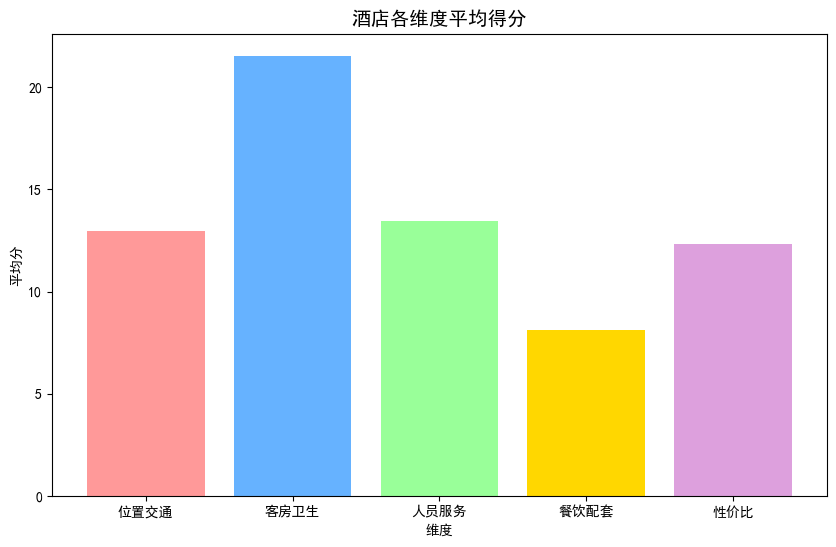

In [23]:
#计算五个维度的平均分
dimensions =['地理位置与交通','客房硬件条件与卫生','人员服务','餐饮与配套设施','综合性价比与整体推荐意愿']
avg_scores = [data[dim].mean() for dim in dimensions]

#简写维度名称
short_names=['位置交通','客房卫生','人员服务','餐饮配套','性价比']

plt.figure(figsize=(10,6))
bars=plt.bar(short_names,avg_scores,color=['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#DDA0DD'])
plt.title("酒店各维度平均得分",fontsize=14,fontweight='bold')
plt.xlabel("维度")
plt.ylabel("平均分")
plt.show()

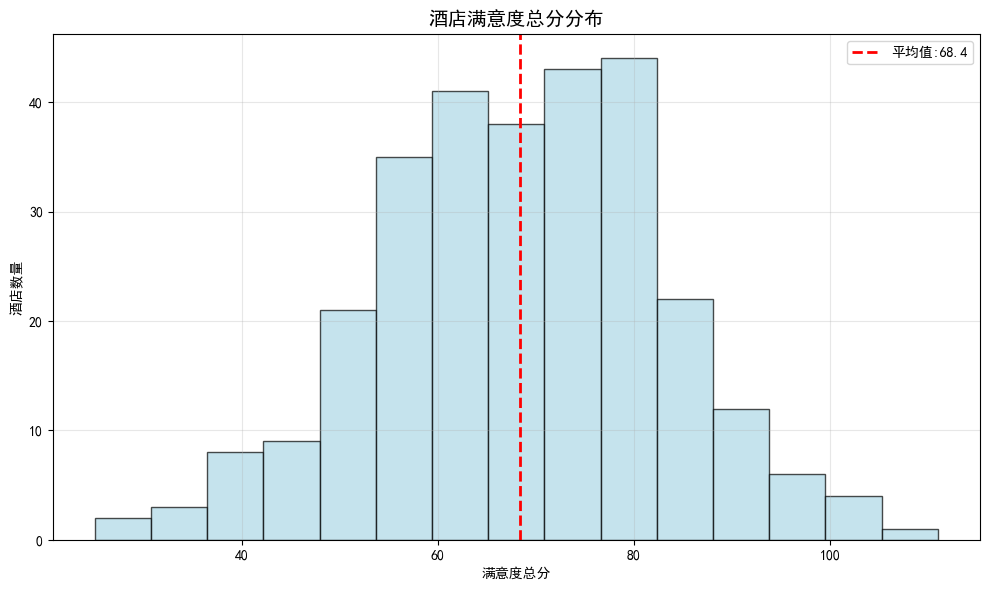

In [26]:
# ==================== 图表2：满意度总分分布直方图 ====================
plt.figure(figsize=(10,6))
plt.hist(data['满意度总分'],bins=15,color='lightblue',edgecolor='black',alpha=0.7)

#添加平均值线
mean_score =data['满意度总分'].mean()
plt.axvline(mean_score,color='red',linestyle='--',linewidth=2,label=f'平均值:{mean_score:.1f}')

plt.title('酒店满意度总分分布',fontsize=14,fontweight='bold')
plt.xlabel('满意度总分')
plt.ylabel('酒店数量')
plt.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()